# TF-IDF Baseline: Logistic Regression

This notebook establishes the classical NLP baseline for the mental-health text classification experiment.

The model uses TF-IDF features followed by Logistic Regression. The same fixed train, validation, and test splits created in `02_dataset_preparation.ipynb` are used here.

## Research purpose

TF-IDF represents text using sparse lexical features. Logistic Regression provides a simple and interpretable baseline before comparing the results with BiLSTM and DistilBERT.

## 1. Import libraries

In [1]:
from pathlib import Path
import time

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load the fixed dataset splits

In [2]:
possible_dirs = [
    Path("data/prepared"),
    Path("../data/prepared")
]

DATA_DIR = None

for directory in possible_dirs:
    if (directory / "train.csv").exists():
        DATA_DIR = directory
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the prepared dataset. "
        "Please run 02_dataset_preparation.ipynb first."
    )

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

Training set: (38115, 2)
Validation set: (8167, 2)
Test set: (8168, 2)


## 3. Separate text and labels

In [3]:
X_train = train_df["text"]
y_train = train_df["label"]

X_val = val_df["text"]
y_val = val_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

print("Training examples:", len(X_train))
print("Validation examples:", len(X_val))
print("Test examples:", len(X_test))

Training examples: 38115
Validation examples: 8167
Test examples: 8168


## 4. Create TF-IDF features

The vectorizer is fitted only on the training data. Validation and test data are transformed using the vocabulary and IDF statistics learned from the training set. This prevents information leakage.

In [4]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF feature matrix shapes:")
print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)

TF-IDF feature matrix shapes:
Train: (38115, 100000)
Validation: (8167, 100000)
Test: (8168, 100000)


## 5. Train Logistic Regression

Class weights are balanced so that the minority classes receive more influence during training. This is appropriate because the dataset has substantial class imbalance.

In [5]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

start_time = time.time()
model.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds.")

Training completed in 24.71 seconds.


## 6. Evaluate on the validation set

The validation set is used for an initial check. The test set is kept for the final model comparison.

In [6]:
y_val_pred = model.predict(X_val_tfidf)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_macro_precision = precision_score(y_val, y_val_pred, average="macro", zero_division=0)
val_macro_recall = recall_score(y_val, y_val_pred, average="macro", zero_division=0)
val_macro_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
val_weighted_f1 = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Macro Precision: {val_macro_precision:.4f}")
print(f"Validation Macro Recall: {val_macro_recall:.4f}")
print(f"Validation Macro F1: {val_macro_f1:.4f}")
print(f"Validation Weighted F1: {val_weighted_f1:.4f}")

Validation Accuracy: 0.7579
Validation Macro Precision: 0.6906
Validation Macro Recall: 0.7417
Validation Macro F1: 0.7073
Validation Weighted F1: 0.7591


## 7. Final evaluation on the test set

Macro F1 is the primary metric because the class distribution is imbalanced.

In [7]:
y_test_pred = model.predict(X_test_tfidf)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
test_macro_recall = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("Test Results")
print("------------")
print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Macro Precision:   {test_macro_precision:.4f}")
print(f"Macro Recall:      {test_macro_recall:.4f}")
print(f"Macro F1:          {test_macro_f1:.4f}")
print(f"Weighted F1:       {test_weighted_f1:.4f}")

Test Results
------------
Accuracy:          0.7512
Macro Precision:   0.6832
Macro Recall:      0.7387
Macro F1:          0.7022
Weighted F1:       0.7524


## 8. Per-class performance

In [8]:
report = classification_report(
    y_test,
    y_test_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

     Anxiety       0.81      0.79      0.80       687
  Depression       0.78      0.62      0.69      2375
       Happy       0.77      0.72      0.74       102
Mentalhealth       0.59      0.70      0.64       292
      Normal       0.88      0.92      0.90      2405
         Sad       0.46      0.70      0.56       246
      Stress       0.50      0.78      0.61       343
    Suicidal       0.68      0.69      0.68      1718

    accuracy                           0.75      8168
   macro avg       0.68      0.74      0.70      8168
weighted avg       0.76      0.75      0.75      8168



## 9. Confusion matrix

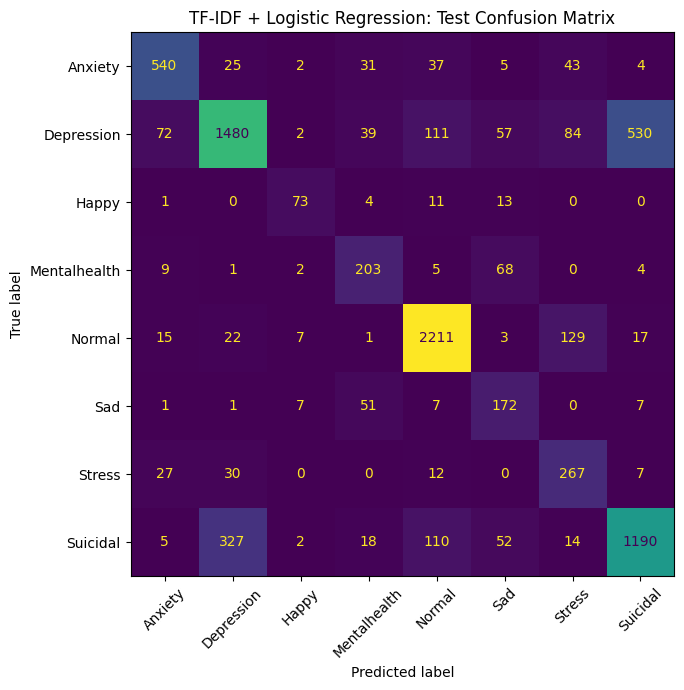

In [9]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
plt.title("TF-IDF + Logistic Regression: Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Save baseline results

The results are saved so that they can later be compared directly with the BiLSTM and DistilBERT experiments.

In [10]:
results_dir = DATA_DIR.parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

baseline_results = pd.DataFrame([{
    "model": "TF-IDF + Logistic Regression",
    "accuracy": test_accuracy,
    "macro_precision": test_macro_precision,
    "macro_recall": test_macro_recall,
    "macro_f1": test_macro_f1,
    "weighted_f1": test_weighted_f1,
    "training_time_seconds": training_time,
    "n_train": len(X_train),
    "n_validation": len(X_val),
    "n_test": len(X_test),
    "n_features": X_train_tfidf.shape[1]
}])

baseline_results.to_csv(results_dir / "tfidf_logistic_regression_results.csv", index=False)
report_df.to_csv(results_dir / "tfidf_logistic_regression_classification_report.csv")

print("Saved results to:")
print(results_dir / "tfidf_logistic_regression_results.csv")
print(results_dir / "tfidf_logistic_regression_classification_report.csv")

Saved results to:
..\data\results\tfidf_logistic_regression_results.csv
..\data\results\tfidf_logistic_regression_classification_report.csv


## 11. Baseline summary

The test-set Macro F1 is the main result that will be compared with the BiLSTM and DistilBERT models.

In [11]:
print("TF-IDF baseline completed.")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Number of TF-IDF features: {X_train_tfidf.shape[1]}")

TF-IDF baseline completed.
Test Macro F1: 0.7022
Test Accuracy: 0.7512
Training time: 24.71 seconds
Number of TF-IDF features: 100000
